In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [21]:
print("Project root:", os.getcwd())  # Check current working directory
print("Folders in root:", os.listdir())  # See what folders it sees

Project root: C:\Users\Administrator\Desktop\sign-language-predictor
Folders in root: ['.git', '.gitignore', '.ipynb_checkpoints', '.venv', 'app', 'archive (4).zip', 'dataset', 'model', 'README.md', 'Untitled.ipynb', 'venv', '\ufeffrequirements.txt']


In [22]:
import os

for root, dirs, files in os.walk('dataset'):
    print(root)

dataset
dataset\asl_alphabet_test
dataset\asl_alphabet_test\asl_alphabet_test
dataset\asl_alphabet_train
dataset\asl_alphabet_train\asl_alphabet_train
dataset\asl_alphabet_train\asl_alphabet_train\A
dataset\asl_alphabet_train\asl_alphabet_train\B
dataset\asl_alphabet_train\asl_alphabet_train\C
dataset\asl_alphabet_train\asl_alphabet_train\D
dataset\asl_alphabet_train\asl_alphabet_train\del
dataset\asl_alphabet_train\asl_alphabet_train\E
dataset\asl_alphabet_train\asl_alphabet_train\F
dataset\asl_alphabet_train\asl_alphabet_train\G
dataset\asl_alphabet_train\asl_alphabet_train\H
dataset\asl_alphabet_train\asl_alphabet_train\I
dataset\asl_alphabet_train\asl_alphabet_train\J
dataset\asl_alphabet_train\asl_alphabet_train\K
dataset\asl_alphabet_train\asl_alphabet_train\L
dataset\asl_alphabet_train\asl_alphabet_train\M
dataset\asl_alphabet_train\asl_alphabet_train\N
dataset\asl_alphabet_train\asl_alphabet_train\nothing
dataset\asl_alphabet_train\asl_alphabet_train\O
dataset\asl_alphabet_trai

In [23]:
train_dir = 'dataset/asl_alphabet_train/asl_alphabet_train'
test_dir = 'dataset/asl_alphabet_test/asl_alphabet_test'

print("Classes in train dir:", os.listdir(train_dir))
print("Number of classes:", len(os.listdir(train_dir)))

Classes in train dir: ['A', 'B', 'C', 'D', 'del', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'nothing', 'O', 'P', 'Q', 'R', 'S', 'space', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Number of classes: 29


In [24]:
import os
print(os.listdir(test_dir))


['A_test.jpg', 'B_test.jpg', 'C_test.jpg', 'D_test.jpg', 'E_test.jpg', 'F_test.jpg', 'G_test.jpg', 'H_test.jpg', 'I_test.jpg', 'J_test.jpg', 'K_test.jpg', 'L_test.jpg', 'M_test.jpg', 'nothing_test.jpg', 'N_test.jpg', 'O_test.jpg', 'P_test.jpg', 'Q_test.jpg', 'R_test.jpg', 'space_test.jpg', 'S_test.jpg', 'T_test.jpg', 'U_test.jpg', 'V_test.jpg', 'W_test.jpg', 'X_test.jpg', 'Y_test.jpg', 'Z_test.jpg']


In [25]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)


target_size = (64, 64)
batch_size = 32

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=target_size,
    batch_size=batch_size,
    class_mode='categorical'
)

Found 87000 images belonging to 29 classes.


In [26]:
import os
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing import image
import numpy as np

# Rebuild label mapping from train generator
label_map = train_generator.class_indices
inv_label_map = {v: k for k, v in label_map.items()}

# Directory where your test images are stored
test_dir = 'dataset/asl_alphabet_test/asl_alphabet_test'

# Load test images manually
x_test = []
y_test = []

for fname in os.listdir(test_dir):
    if fname.endswith('.jpg'):
        img_path = os.path.join(test_dir, fname)
        img = image.load_img(img_path, target_size=target_size)
        img_array = image.img_to_array(img) / 255.0
        x_test.append(img_array)

        # Extract label from filename like 'A_test.jpg' -> 'A'
        label = fname.split('_')[0]
        y_test.append(label_map[label])

x_test = np.array(x_test)
y_test = to_categorical(y_test, num_classes=len(label_map))


In [27]:
#gonna train model

model = Sequential([
         Conv2D(32,(3,3), activation='relu', input_shape=(64,64,3)),
         MaxPooling2D(pool_size=(2,2)),
         Conv2D(64,(3,3), activation='relu'),
         MaxPooling2D(pool_size=(2,2)),
         Conv2D(128,(3,3), activation='relu'),
         MaxPooling2D(pool_size=(2,2)),

         Flatten(),
         Dense(128, activation='relu'),
         Dropout(0.5),
         Dense(train_generator.num_classes, activation='softmax')
                  ])

In [28]:
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [31]:
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=10, 
    validation_data=(x_test, y_test)
)

Epoch 1/10
2718/2718 ━━━━━━━━━━━━━━━━━━━━ 312s 115ms/step - accuracy: 0.7068 - loss: 0.8501 - val_accuracy: 0.9643 - val_loss: 0.1455
Epoch 2/10
2718/2718 ━━━━━━━━━━━━━━━━━━━━ 0s 33us/step - accuracy: 0.8125 - loss: 0.5187 - val_accuracy: 0.9643 - val_loss: 0.1431
Epoch 3/10
   1/2718 ━━━━━━━━━━━━━━━━━━━━ 6:01 133ms/step - accuracy: 0.7812 - loss: 0.5925

C:\Users\Administrator\anaconda3\Lib\contextlib.py:158: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


2718/2718 ━━━━━━━━━━━━━━━━━━━━ 319s 117ms/step - accuracy: 0.8083 - loss: 0.5423 - val_accuracy: 0.9286 - val_loss: 0.1083
Epoch 4/10
2718/2718 ━━━━━━━━━━━━━━━━━━━━ 0s 23us/step - accuracy: 0.8750 - loss: 0.3060 - val_accuracy: 0.9286 - val_loss: 0.1058
Epoch 5/10
2718/2718 ━━━━━━━━━━━━━━━━━━━━ 302s 111ms/step - accuracy: 0.8615 - loss: 0.3991 - val_accuracy: 1.0000 - val_loss: 0.0122
Epoch 6/10
2718/2718 ━━━━━━━━━━━━━━━━━━━━ 0s 26us/step - accuracy: 0.9062 - loss: 0.4039 - val_accuracy: 1.0000 - val_loss: 0.0100
Epoch 7/10
2718/2718 ━━━━━━━━━━━━━━━━━━━━ 298s 109ms/step - accuracy: 0.8883 - loss: 0.3237 - val_accuracy: 1.0000 - val_loss: 0.0079
Epoch 8/10
2718/2718 ━━━━━━━━━━━━━━━━━━━━ 0s 26us/step - accuracy: 0.8750 - loss: 0.4099 - val_accuracy: 1.0000 - val_loss: 0.0091
Epoch 9/10
2718/2718 ━━━━━━━━━━━━━━━━━━━━ 304s 112ms/step - accuracy: 0.9081 - loss: 0.2708 - val_accuracy: 1.0000 - val_loss: 0.0012
Epoch 10/10
2718/2718 ━━━━━━━━━━━━━━━━━━━━ 0s 30us/step - accuracy: 0.8750 - loss:

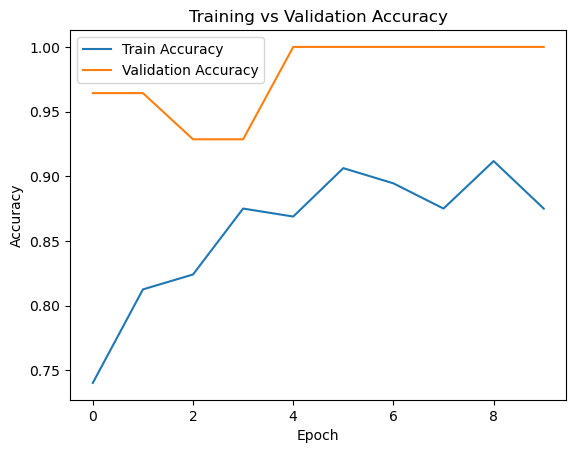

In [32]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.show()

In [41]:
model.save('app/model_v2.keras')  # save inside your app folder

In [40]:
from tensorflow.keras.preprocessing import image
import numpy as np

# Load and preprocess image
img_path = 'model\sign.jpg'
img = image.load_img(img_path, target_size=(64, 64))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred_prob = model.predict(img_array)
pred_class_idx = np.argmax(pred_prob, axis=1)[0]

# Map back to label
class_indices = train_generator.class_indices
inv_class_indices = {v: k for k, v in class_indices.items()}
predicted_label = inv_class_indices[pred_class_idx]

print("Predicted Sign:", predicted_label)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Predicted Sign: Y


In [44]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model

# Load your saved model
model = load_model('app/model_v2.keras')  # or 'model.h5' depending on your save format

# Mapping from model output indices to ASL letters/classes
labels_map = [
    'A', 'B', 'C', 'D', 'del', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 
    'nothing', 'O', 'P', 'Q', 'R', 'S', 'space', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z'
]

# Load image
img_path = 'model/sign.jpg'
img = cv2.imread(img_path)

if img is None:
    raise ValueError(f"Image not found at {img_path}")

# Preprocess the image
# 1. Convert BGR to RGB (model expects RGB)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 2. Resize to model input size (64x64)
img_resized = cv2.resize(img_rgb, (64, 64), interpolation=cv2.INTER_AREA)

# 3. Normalize pixel values to [0,1]
img_normalized = img_resized.astype('float32') / 255.0

# 4. Expand dimensions to add batch size (1, 64, 64, 3)
img_input = np.expand_dims(img_normalized, axis=0)

# Predict
pred_probs = model.predict(img_input)[0]

# Get highest probability class index
pred_class_idx = np.argmax(pred_probs)

# Get corresponding label and confidence
pred_label = labels_map[pred_class_idx]
confidence = pred_probs[pred_class_idx]

print(f"Predicted Sign: {pred_label} with confidence: {confidence*100:.2f}%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
Predicted Sign: U with confidence: 33.83%


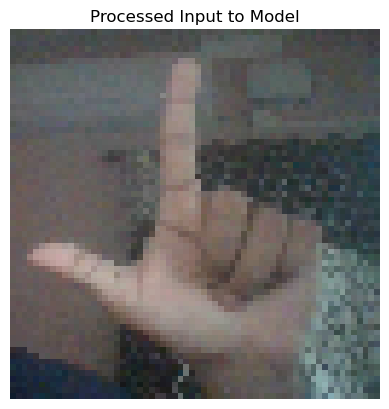

In [37]:
import matplotlib.pyplot as plt
plt.imshow(img_array[0].squeeze(), cmap='gray')
plt.title("Processed Input to Model")
plt.axis('off')
plt.show()

In [5]:
from tensorflow.keras.preprocessing import image
import numpy as np


model = load_model('app/model_v2.keras')
# Load and preprocess image
img_path = 'debug_roi.jpg'
img = image.load_img(img_path, target_size=(64, 64))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred_prob = model.predict(img_array)
pred_class_idx = np.argmax(pred_prob, axis=1)[0]

labels_map = [
    'A', 'B', 'C', 'D', 'del', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 
    'nothing', 'O', 'P', 'Q', 'R', 'S', 'space', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']

predicted_labels = labels_map[pred_class_idx]

print("Predicted Sign:", predicted_labels)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Predicted Sign: Y


In [1]:
from tensorflow.keras.models import load_model

model = load_model('app/model_v2.keras')
print("Input shape:", model.input_shape)


Input shape: (None, 64, 64, 3)
